#ONLINE PAYMENT FRAUD DETECTION SYSTEM :


### Importing required libraries:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

###Data Loading $ Understanding:

In [2]:
df = pd.read_csv("/content/drive/MyDrive/ML_Project/online-payment-fraud-messy.csv")

In [3]:
df.head()

,step,type,Amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,36.0,TRANSFER,200903.880486,C710114584,136782.264134,-74248.267499,C289543788,2.446235e+06,2.668724e+06,0,0.0
1,299.0,CASH_OUT,403111.433429,NaN,85094.643247,-3394.172332,C1321956796,-7.866686e+04,NaN,0,0.0
2,47.0,PAYMENT,43774.124791,C858080310,10273.363625,124362.265011,M1148569236,-1.207433e+04,3.480232e+05,0,0.0
3,139.0,CASH_OUT,234184.174806,C434819257,-43510.972931,-95988.727547,C490792373,6.360514e+05,7.978805e+05,0,0.0
4,542.0,CASH_OUT,72767.178906,C1962786394,53398.207482,-3388.338161,C1840044702,8.590555e+06,8.540274e+06,0,0.0


In [4]:
df.shape

(309000, 11)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 309000 entries, 0 to 308999
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   step            293553 non-null  float64
 1   type            294330 non-null  object 
 2   Amount          293548 non-null  float64
 3   nameOrig        294040 non-null  object 
 4   oldbalanceOrg   293552 non-null  float64
 5   newbalanceOrig  293523 non-null  float64
 6   nameDest        284730 non-null  object 
 7   oldbalanceDest  293538 non-null  float64
 8   newbalanceDest  293549 non-null  float64
 9   isFraud         309000 non-null  int64  
 10  isFlaggedFraud  293560 non-null  float64
dtypes: float64(7), int64(1), object(3)
memory usage: 25.9+ MB


In [6]:
df.describe()

,step,Amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,293553.000000,2.935480e+05,2.935520e+05,2.935230e+05,2.935380e+05,2.935490e+05,309000.000000,293560.000000
mean,243.392055,1.979694e+05,8.623799e+05,8.992192e+05,1.239022e+06,1.372412e+06,0.001288,0.000003
std,142.756413,7.441428e+05,3.119278e+06,3.305548e+06,4.527001e+06,5.049471e+06,0.035866,0.001846
min,1.000000,-9.009579e+04,-4.147805e+05,-4.186588e+05,-5.591080e+05,-6.551015e+05,0.000000,0.000000
25%,155.000000,1.912845e+04,-2.573872e+04,-3.365536e+04,5.872716e+03,2.092699e+04,0.000000,0.000000
50%,239.000000,7.960389e+04,5.468017e+04,5.380597e+04,2.011603e+05,2.640204e+05,0.000000,0.000000
75%,335.000000,2.154631e+05,1.749472e+05,1.966067e+05,9.995508e+05,1.172001e+06,0.000000,0.000000
max,741.000000,1.331507e+08,9.398590e+07,1.321326e+08,6.547039e+08,8.902181e+08,1.000000,1.000000


In [7]:
df.columns

Index(['step ', 'type', 'Amount', 'nameOrig', 'oldbalanceOrg',
       'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest',
       'isFraud', 'isFlaggedFraud'],
      dtype='object')

missing values :

In [8]:
df.isnull().sum()

,0
step,15447
type,14670
Amount,15452
nameOrig,14960
oldbalanceOrg,15448
newbalanceOrig,15477
nameDest,24270
oldbalanceDest,15462
newbalanceDest,15451
isFraud,0


In [9]:
(df.isnull().sum() / len(df)) * 100

,0
step,4.999029
type,4.747573
Amount,5.000647
nameOrig,4.841424
oldbalanceOrg,4.999353
newbalanceOrig,5.008738
nameDest,7.854369
oldbalanceDest,5.003883
newbalanceDest,5.000324
isFraud,0.000000


In [10]:
df.duplicated().sum()

np.int64(9000)

 #### Fixing column names : To remove inconsistencies like spaces and casing issues

In [11]:
df.columns = df.columns.str.strip().str.lower()

In [12]:
df.columns

Index(['step', 'type', 'amount', 'nameorig', 'oldbalanceorg', 'newbalanceorig',
       'namedest', 'oldbalancedest', 'newbalancedest', 'isfraud',
       'isflaggedfraud'],
      dtype='object')

#### Univariate Analysis:

In [13]:
df["isfraud"].value_counts()

,count
isfraud,
0,308602
1,398


<Axes: xlabel='isfraud'>

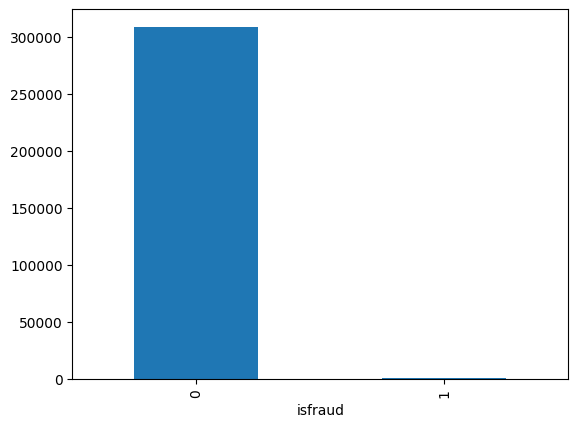

In [14]:
df["isfraud"].value_counts().plot(kind="bar")



*  Fraudulent transactions are extremely rare compared to non-fraud transactions.
* The dataset is highly imbalanced.




In [15]:
# for categorical column :
df["type"].value_counts()

,count
type,
CASH_OUT,84733
PAYMENT,81495
CASH_IN,53144
TRANSFER,20320
cashout,15465
cash_out,13339
payment,12581
cash_in,8341
transfer,3164


#### Cleaning Categorical Labels in `type` Column before analysis :

In [16]:
df["type"].unique()

array(['TRANSFER', 'CASH_OUT', 'PAYMENT', 'CASH_IN', nan, 'transfer',
       'cash_in', 'cashout', 'payment', 'debit', 'cash_out', 'DEBIT'],
      dtype=object)

In [17]:
df["type"] = df["type"].str.strip().str.upper()
df['type'] = df['type'].str.replace('_', '', regex=False)

In [18]:
df["type"].unique()

array(['TRANSFER', 'CASHOUT', 'PAYMENT', 'CASHIN', nan, 'DEBIT'],
      dtype=object)

In [19]:
print(df["type"].isnull().sum())

14670


#####  this column `type` have nan values present .

<Axes: xlabel='type'>

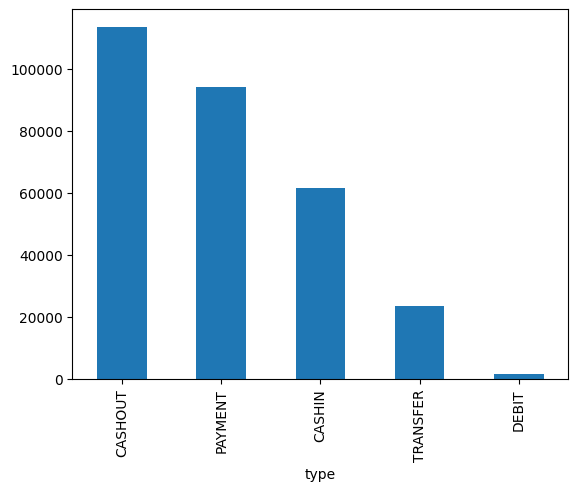

In [20]:
df["type"].value_counts().plot(kind="bar")



---


##### Insights from Transaction Type Distribution
- Transaction types are unevenly distributed across the dataset.
- CASHOUT is the most common transaction type, followed by PAYMENT.
- DEBIT transactions are very rare compared to other categories.

---



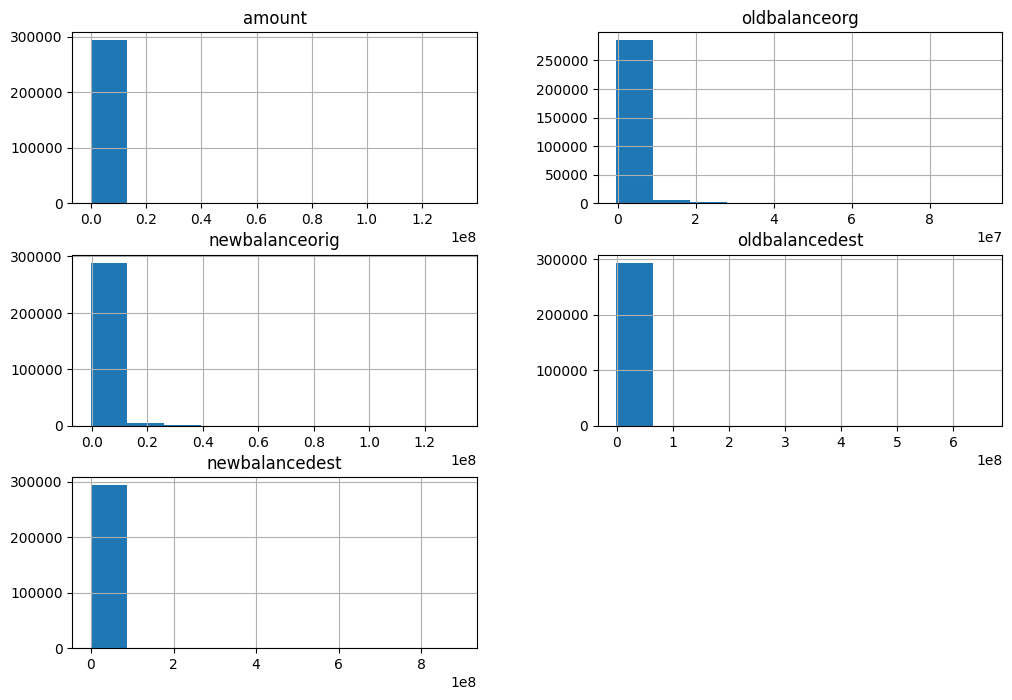

In [21]:
# for numerical columns:
num_cols = ["amount" , "oldbalanceorg" , "newbalanceorig" ,"oldbalancedest" , "newbalancedest"]
df[num_cols].hist(figsize=(12,8))
plt.show()

##### Numerical Feature Insights:
- Transaction amount and balance columns are highly right-skewed.
- Most values are concentrated in lower ranges, while few extreme values exist.
- This indicates presence of outliers and non-normal distributions.

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


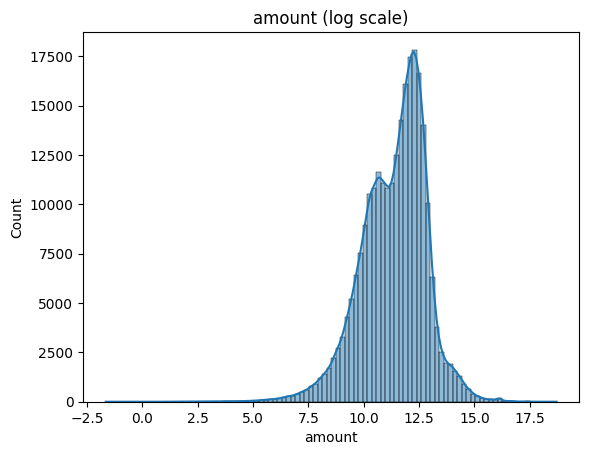

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


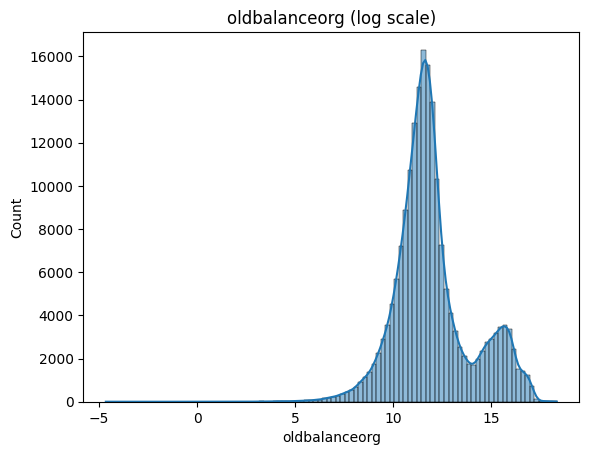

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


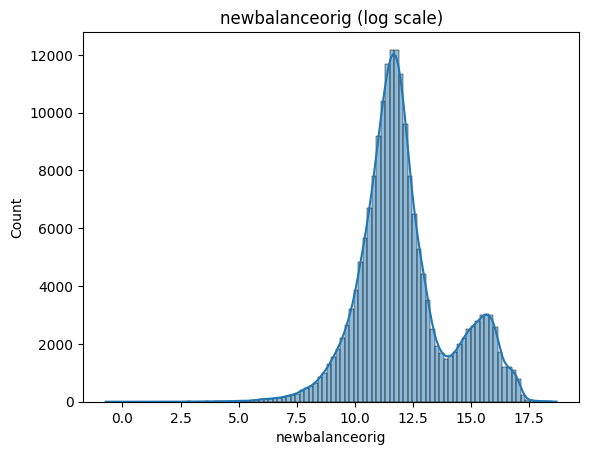

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


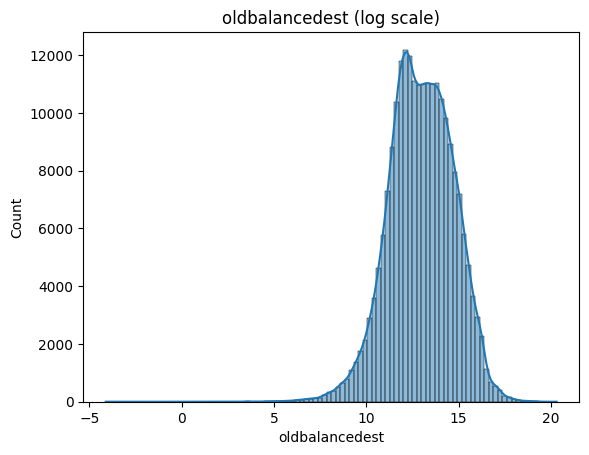

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


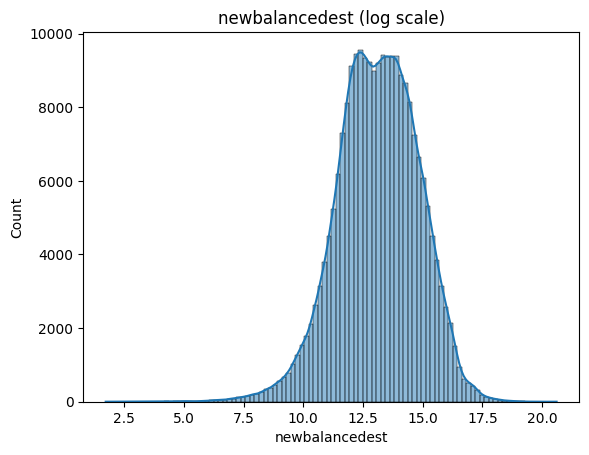

In [22]:
# for numerical column :
for col in num_cols:
    sns.histplot(np.log1p(df[col]), bins=100, kde=True) # log1p shrinks large values so graph becomes readable
    plt.title(col + " (log scale)")
    plt.show()

#####

* The data was highly right skewed so i applied log transformation to reduce skewness and make the distribution more suitable for analysis and modeling.




### BIVARIATE ANALYSIS:

In [23]:
pd.crosstab(df['type'], df['isfraud'], normalize='index') * 100 # to observe which type have most % of fraud

isfraud,0,1
type,,
CASHIN,100.000000,0.000000
CASHOUT,99.838819,0.161181
DEBIT,100.000000,0.000000
PAYMENT,100.000000,0.000000
TRANSFER,99.139840,0.860160


##### Fraud by Transaction Type :
- Fraud cases are concentrated in specific transaction types.
- TRANSFER and CASHOUT generally show higher fraud risk.

<Axes: xlabel='isfraud', ylabel='amount'>

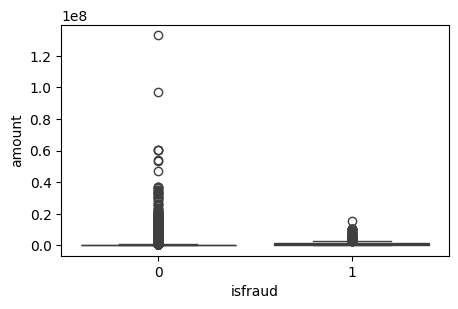

In [24]:
plt.figure(figsize=(5,3))
sns.boxplot(x = "isfraud" , y= "amount" , data = df)

<Axes: xlabel='isfraud', ylabel='oldbalanceorg'>

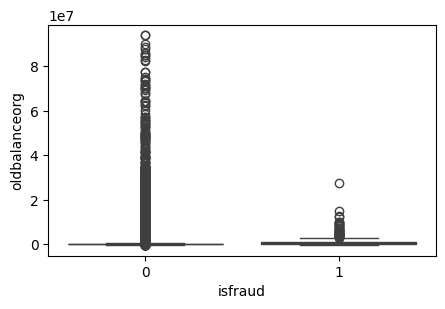

In [25]:
plt.figure(figsize=(5,3))
sns.boxplot(x = "isfraud" , y="oldbalanceorg" , data = df)

<Axes: xlabel='isfraud', ylabel='newbalanceorig'>

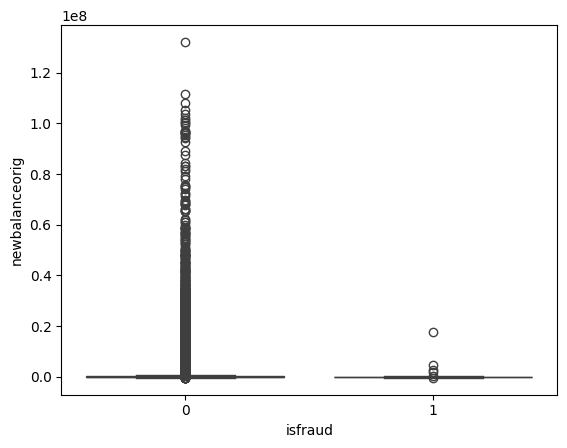

In [26]:
sns.boxplot(x = "isfraud" , y="newbalanceorig" , data = df)

<Axes: xlabel='isfraud', ylabel='oldbalancedest'>

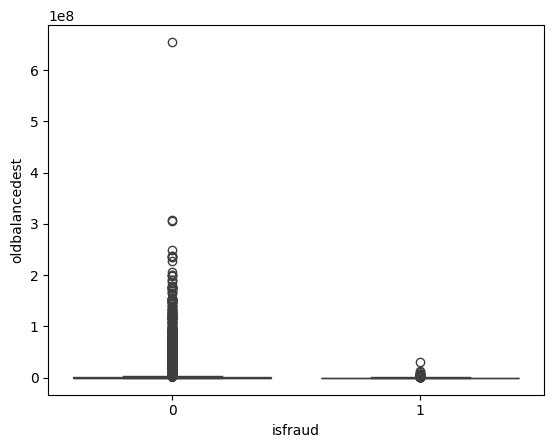

In [27]:
sns.boxplot(x = "isfraud" , y="oldbalancedest" , data = df)

<Axes: xlabel='isfraud', ylabel='newbalancedest'>

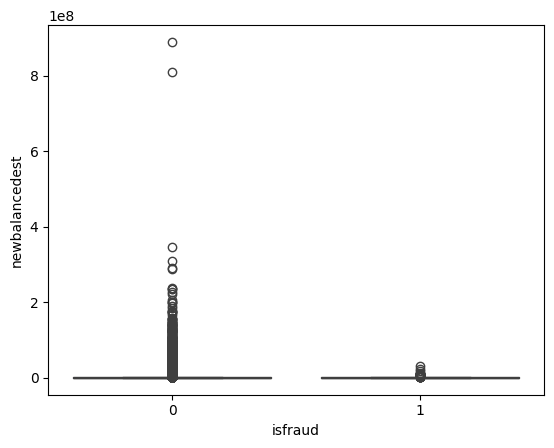

In [28]:
sns.boxplot(x = "isfraud" , y="newbalancedest" , data = df)

<Axes: xlabel='step'>

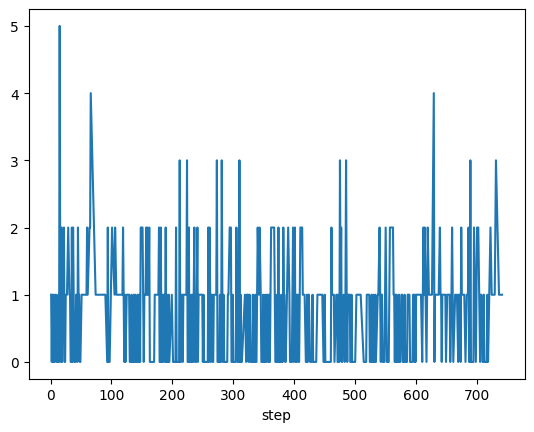

In [29]:
df.groupby('step')['isfraud'].sum().plot()


### Correlation :

<Axes: >

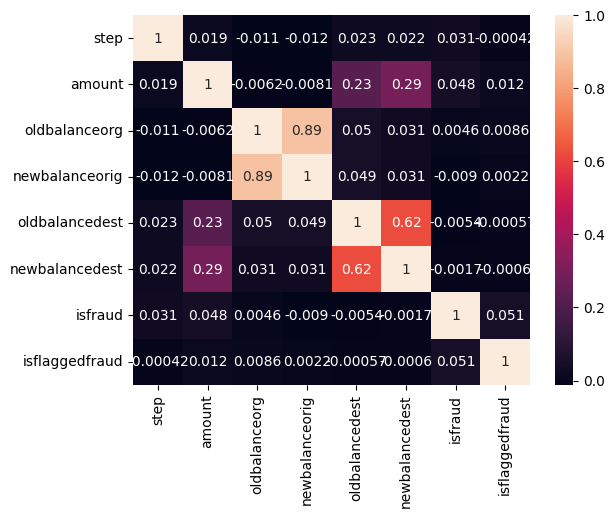

In [30]:
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True)

##### Correlation Insights:
- Balance-related variables show moderate to strong relationships.
- Some features may contain overlapping information.
- Feature selection or engineering may improve model efficiency.






---





---


### Key Findings from Exploratory Data Analysis :

1. The target variable is highly imbalanced with very few fraud cases.
2. Transaction types are unevenly distributed; CASHOUT and PAYMENT are most common.
3. Fraud risk appears concentrated in specific transaction types such as CASHOUT and TRANSFER.
4. Numerical variables like amount and balances are highly right-skewed.
5. Multiple outliers exist in financial features.
6. Some missing values and inconsistent labels were present and need preprocessing.
7. Balance-related variables may be useful predictors.


---



## DATA CLEANING :

##### Handling missing values :

In [31]:
df.isnull().sum()

,0
step,15447
type,14670
amount,15452
nameorig,14960
oldbalanceorg,15448
newbalanceorig,15477
namedest,24270
oldbalancedest,15462
newbalancedest,15451
isfraud,0


In [32]:
df["step"] = df["step"].fillna(df["step"].median())
df["amount"] = df["amount"].fillna(df["step"].median())
df["newbalanceorig"] = df["newbalanceorig"].fillna(df["newbalanceorig"].median())
df["oldbalanceorg"] = df["oldbalanceorg"].fillna(df["oldbalanceorg"].median())
df["oldbalancedest"] = df["oldbalancedest"].fillna(df["oldbalancedest"].median())
df["newbalancedest"] = df["newbalancedest"].fillna(df["newbalancedest"].median())

df["type"] = df["type"].fillna(df["type"].mode()[0])
df["nameorig"] = df["nameorig"].fillna("Unknown")
df["namedest"] = df["namedest"].fillna("Unknown")
df["isflaggedfraud"] = df["isflaggedfraud"].fillna(df["isflaggedfraud"].mode()[0])


In [33]:
print(df.isnull().sum())

step              0
type              0
amount            0
nameorig          0
oldbalanceorg     0
newbalanceorig    0
namedest          0
oldbalancedest    0
newbalancedest    0
isfraud           0
isflaggedfraud    0
dtype: int64


##### Handling duplicate values :

In [34]:
print(df.duplicated().sum())

9000


In [35]:
df = df.drop_duplicates()

##### Removing useless columns - `nameorig`, `namedest` :


In [36]:
df = df.drop(columns=["nameorig", "namedest"])

In [37]:
df.columns

Index(['step', 'type', 'amount', 'oldbalanceorg', 'newbalanceorig',
       'oldbalancedest', 'newbalancedest', 'isfraud', 'isflaggedfraud'],
      dtype='object')

In [38]:
df.shape

(300000, 9)

##### Outlier Handling:

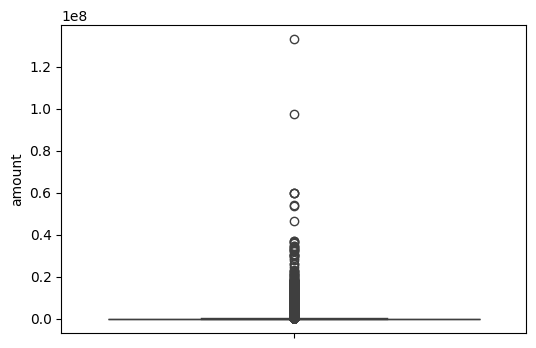

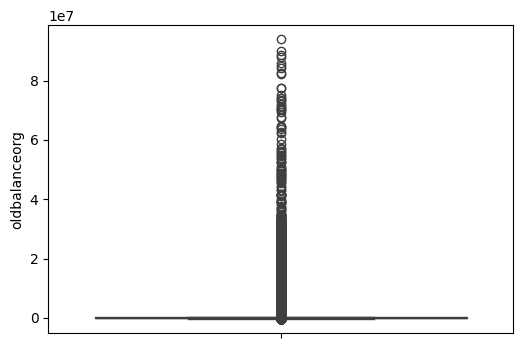

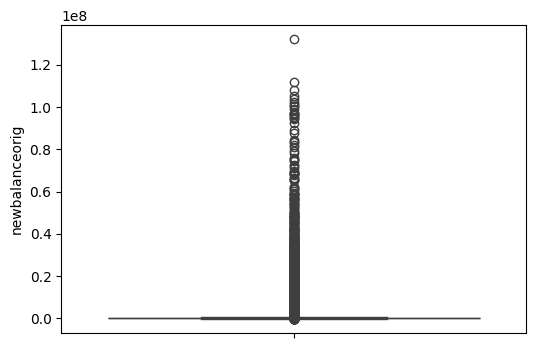

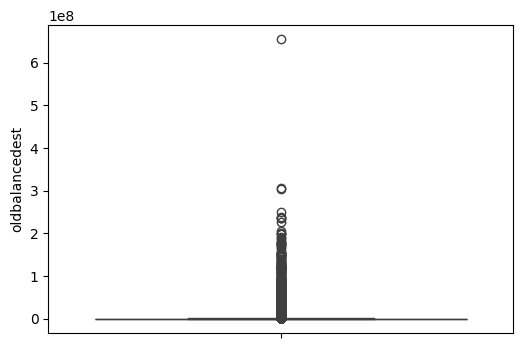

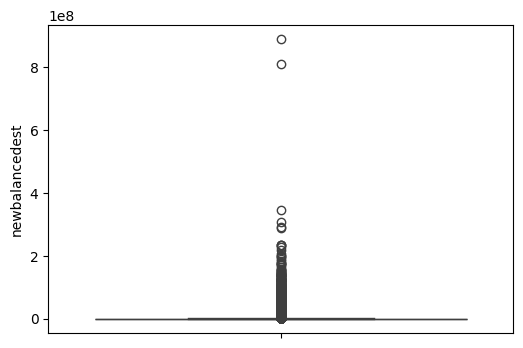

In [39]:
cols = ["amount" ,"oldbalanceorg" ,"newbalanceorig" ,"oldbalancedest" ,"newbalancedest"]
for col in cols:
  fig = plt.figure(figsize=(6,4))
  sns.boxplot(df[col])
  plt.show()


In [40]:
cols = ["amount" ,"oldbalanceorg" ,"newbalanceorig" ,"oldbalancedest" ,"newbalancedest"]
for col in cols:
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)
  IQR = Q3 - Q1
  lower = Q1 - 1.5*IQR
  upper = Q3 + 1.5*IQR
  # CLIPPING :
  df[col] = df[col].clip(lower , upper )


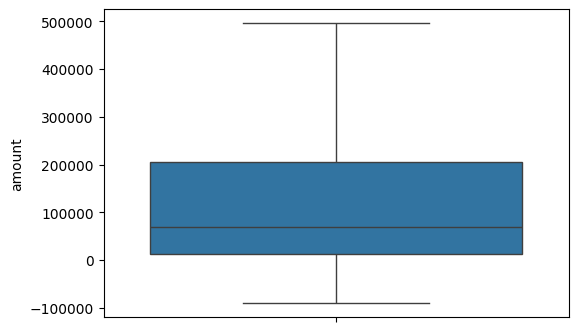

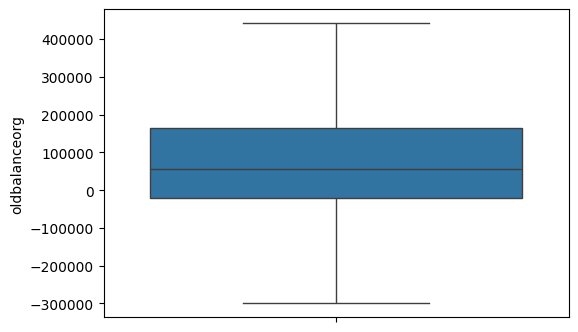

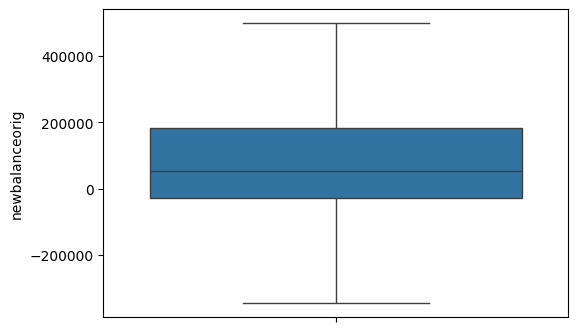

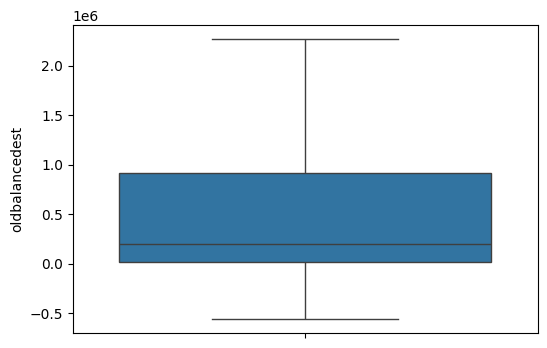

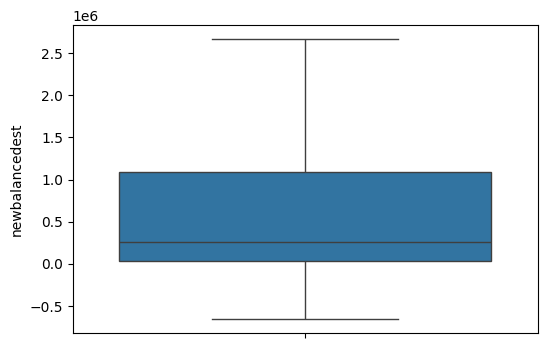

In [41]:
for col in cols:
  fig = plt.figure(figsize=(6,4))
  sns.boxplot(df[col])
  plt.show()

### MODEL TRAINING:

#### Splitting training and testing data:

In [42]:
x = df.drop(columns=["isfraud"])
y = df["isfraud"]

In [43]:
from sklearn.model_selection import train_test_split
x_train , x_test , y_train , y_test = train_test_split(x , y , test_size = 0.2 ,stratify=y , random_state = 42)

#### Encoding the `type` column :

In [44]:
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(handle_unknown="ignore" , sparse_output = False)
ohe.fit(x_train[["type"]])
x_train_encode = ohe.transform(x_train[["type"]])
x_test_encode = ohe.transform(x_test[["type"]])

In [45]:
cols_encoded = ohe.get_feature_names_out(["type"])
print(cols_encoded)

['type_CASHIN' 'type_CASHOUT' 'type_DEBIT' 'type_PAYMENT' 'type_TRANSFER']


In [46]:
# converting the encoded columns to dataframe :
x_train_encode_df = pd.DataFrame(x_train_encode , columns = cols_encoded , index = x_train.index)
x_test_encode_df = pd.DataFrame(x_test_encode , columns = cols_encoded , index = x_test.index)

In [47]:
# concatination of encoded with main :
x_train = pd.concat([x_train , x_train_encode_df] , axis = 1 )
x_test = pd.concat([x_test , x_test_encode_df] , axis = 1)


In [48]:
# dropping the original column:
x_train = x_train.drop("type" , axis = 1)
x_test = x_test.drop("type" , axis = 1)

#### Scaling features using the StandardScaler:

In [49]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

feature eng:

In [73]:
df["balance_diff_orig"] = df["oldbalanceorg"] - df["newbalanceorig"]
df["balance_diff_dest"] = df["newbalancedest"] - df["oldbalancedest"]

#### Model Training :

using logistic regression:

In [74]:
from sklearn.linear_model import LogisticRegression
LR = LogisticRegression(class_weight = "balanced" , max_iter=1000)
LR.fit(x_train_scaled , y_train)
y_pred_lr = LR.predict(x_test_scaled)

In [76]:
from sklearn.metrics import classification_report , accuracy_score , recall_score , precision_score , f1_score
print(classification_report(y_test , y_pred_lr))
print("accuracy : ", accuracy_score(y_test , y_pred_lr))
print("recall : " , recall_score(y_test , y_pred_lr))
print("precision : " , precision_score(y_test , y_pred_lr))
print("f1_score : " ,f1_score(y_test , y_pred_lr))


              precision    recall  f1-score   support

           0       1.00      0.87      0.93     59922
           1       0.01      0.94      0.02        78

    accuracy                           0.87     60000
   macro avg       0.50      0.90      0.47     60000
weighted avg       1.00      0.87      0.93     60000

accuracy :  0.8662833333333333
recall :  0.9358974358974359
precision :  0.009022370535162525
f1_score :  0.017872444607663115


THRESHOLD TUNNING:

In [77]:
y_prob = LR.predict_proba(x_test_scaled)[: ,1]

In [78]:
threshold = 0.8
y_pred_new = (y_prob > threshold).astype(int)

In [79]:
from sklearn.metrics import classification_report , accuracy_score , recall_score , precision_score , f1_score
print(classification_report(y_test , y_pred_new))
print("accuracy : ", accuracy_score(y_test , y_pred_new))
print("recall : " , recall_score(y_test , y_pred_new))
print("precision : " , precision_score(y_test , y_pred_new))
print("f1_score : " ,f1_score(y_test , y_pred_new))

              precision    recall  f1-score   support

           0       1.00      0.97      0.98     59922
           1       0.03      0.85      0.06        78

    accuracy                           0.97     60000
   macro avg       0.52      0.91      0.52     60000
weighted avg       1.00      0.97      0.98     60000

accuracy :  0.96775
recall :  0.8461538461538461
precision :  0.033182503770739065
f1_score :  0.06386066763425254


using random forest classifier

In [80]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(class_weight = "balanced" , n_estimators = 100 , n_jobs = -1 , random_state = 42)
rf.fit(x_train , y_train)
y_pred_rf = rf.predict(x_test)

In [81]:
from sklearn.metrics import classification_report , accuracy_score , recall_score , precision_score , f1_score
print(classification_report(y_test , y_pred_rf))
print("accuracy : ", accuracy_score(y_test , y_pred_rf))
print("recall : " , recall_score(y_test , y_pred_rf))
print("precision : " , precision_score(y_test , y_pred_rf))
print("f1_score : " ,f1_score(y_test , y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     59922
           1       0.83      0.32      0.46        78

    accuracy                           1.00     60000
   macro avg       0.92      0.66      0.73     60000
weighted avg       1.00      1.00      1.00     60000

accuracy :  0.9990333333333333
recall :  0.32051282051282054
precision :  0.8333333333333334
f1_score :  0.46296296296296297


Thresholdd tuning

In [82]:
y_prob_rf = rf.predict_proba(x_test)[: ,1]

In [83]:
threshold = 0.3
y_pred_rf_new = (y_prob_rf > threshold).astype(int)

In [84]:
print(classification_report(y_test , y_pred_rf_new))
print("accuracy : ", accuracy_score(y_test , y_pred_rf_new))
print("recall : " , recall_score(y_test , y_pred_rf_new))
print("precision : " , precision_score(y_test , y_pred_rf_new))
print("f1_score : " ,f1_score(y_test , y_pred_rf_new))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     59922
           1       0.83      0.49      0.61        78

    accuracy                           1.00     60000
   macro avg       0.91      0.74      0.81     60000
weighted avg       1.00      1.00      1.00     60000

accuracy :  0.9992
recall :  0.48717948717948717
precision :  0.8260869565217391
f1_score :  0.6129032258064516


applying smote:

In [85]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state = 42)
x_train_smote , y_train_smote = smote.fit_resample(x_train , y_train)

In [86]:
rf.fit(x_train_smote , y_train_smote)
y_pred_rf_smote = rf.predict(x_test)

In [87]:
print(classification_report(y_test , y_pred_rf_new))
print("accuracy : ", accuracy_score(y_test , y_pred_rf_new))
print("recall : " , recall_score(y_test , y_pred_rf_new))
print("precision : " , precision_score(y_test , y_pred_rf_new))
print("f1_score : " ,f1_score(y_test , y_pred_rf_new))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     59922
           1       0.83      0.49      0.61        78

    accuracy                           1.00     60000
   macro avg       0.91      0.74      0.81     60000
weighted avg       1.00      1.00      1.00     60000

accuracy :  0.9992
recall :  0.48717948717948717
precision :  0.8260869565217391
f1_score :  0.6129032258064516


In [88]:
print(y_train.value_counts())
print(y_train_smote.value_counts())


isfraud
0    239690
1       310
Name: count, dtype: int64
isfraud
0    239690
1    239690
Name: count, dtype: int64




---



 using xgboost classifier :

In [89]:
pip install xgboost

In [90]:
from xgboost import XGBClassifier

In [92]:
scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]

In [93]:
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss'
)


In [95]:
xgb.fit(x_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=-1,
              num_parallel_tree=None, ...)

In [97]:
y_prob = xgb.predict_proba(x_test)[:, 1]

In [103]:
threshold = 0.45
y_pred = (y_prob > threshold).astype(int)

In [104]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))
print("accuracy : ", accuracy_score(y_test, y_pred))
print("recall : ", recall_score(y_test, y_pred))
print("precision : ", precision_score(y_test, y_pred))
print("f1_score : ", f1_score(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     59922
           1       0.24      0.68      0.36        78

    accuracy                           1.00     60000
   macro avg       0.62      0.84      0.68     60000
weighted avg       1.00      1.00      1.00     60000

accuracy :  0.9968
recall :  0.6794871794871795
precision :  0.2409090909090909
f1_score :  0.35570469798657717


saving the model : pickle file

In [116]:
import pickle
pickle.dump(xgb, open("xgb_fraud_model.pkl", "wb"))
pickle.dump(ohe, open("encoder.pkl", "wb"))
feature_columns = x_train.columns.tolist()
pickle.dump(feature_columns, open("features.pkl", "wb"))